In [1]:
import wandb
from tqdm import tqdm
import pandas as pd

from functools import lru_cache
from matplotlib import pyplot as plt

In [13]:
WANDB_API = wandb.Api()


In [42]:
# student-resnet18-32-basis-bn-v2:prcaposdef-seed1: 
# student-resnet18-32-basis-bn-v2:prcaposdef--centered-seed1: kitchen-sink/runs/0y0929bu
# student-resnet18-32-basis-bn-v2:prcaposdef-seed1: p16i/xaikd-s52-revised-distillation/mphbqq77

MAPPING_RUNID = {
    "sum-normalized--uncentered": "p16i/kitchen-sink/runs/n1qvph55",
    "sum-normalized--centered": "p16i/kitchen-sink/runs/0y0929bu",   
    "u1-normalized--uncentered": "p16i/xaikd-s52-revised-distillation/mphbqq77"
}

In [43]:


def get_df_columns(run, columns, verbose=False):
    rows = []

    for row in tqdm((run.scan_history(
        keys=[
            "epoch",
            *columns,
        ],
        page_size=100000 * 10000,
    )), disable=not verbose):
        rows.append(row)
        
    return pd.DataFrame(rows)


@lru_cache
def read_stats_from_run(run_path):
    run = WANDB_API.run(run_path)
    df = get_df_columns(run, ["train_loss_kd_epoch", "train_loss_layer_epoch", "train_auroc"])
    df_2 = get_df_columns(run, [ "val_loss_kd", "val_loss_layer",  "val_auroc", "best_val_auroc", ])

    return pd.merge(df, df_2, on="epoch")
        

read_stats_from_run(MAPPING_RUNID["sum-normalized--uncentered"])

,epoch,train_loss_kd_epoch,train_loss_layer_epoch,train_auroc,val_loss_kd,val_loss_layer,val_auroc,best_val_auroc
0,0,0.690072,2.848880,0.515475,0.695921,1.804808,0.512426,0.512426
1,1,0.683416,1.413692,0.527479,0.693501,1.311747,0.559526,0.559526
2,2,0.679650,1.200881,0.549444,0.689613,1.170558,0.612489,0.612489
3,3,0.675313,1.141140,0.503604,0.678090,1.168055,0.603785,0.612489
4,4,0.673874,1.098957,0.504128,0.680949,1.126744,0.607967,0.612489
5,5,0.665083,1.053305,0.539277,0.661830,1.018983,0.686886,0.686886
6,6,0.666179,1.013289,0.559016,0.666799,1.088982,0.675186,0.686886
7,7,0.652977,0.985180,0.593953,0.669271,0.974152,0.687138,0.687138
8,8,0.640442,0.957132,0.624658,0.710840,0.991586,0.590394,0.687138
9,9,0.634391,0.925686,0.701799,0.656779,0.939168,0.719991,0.719991


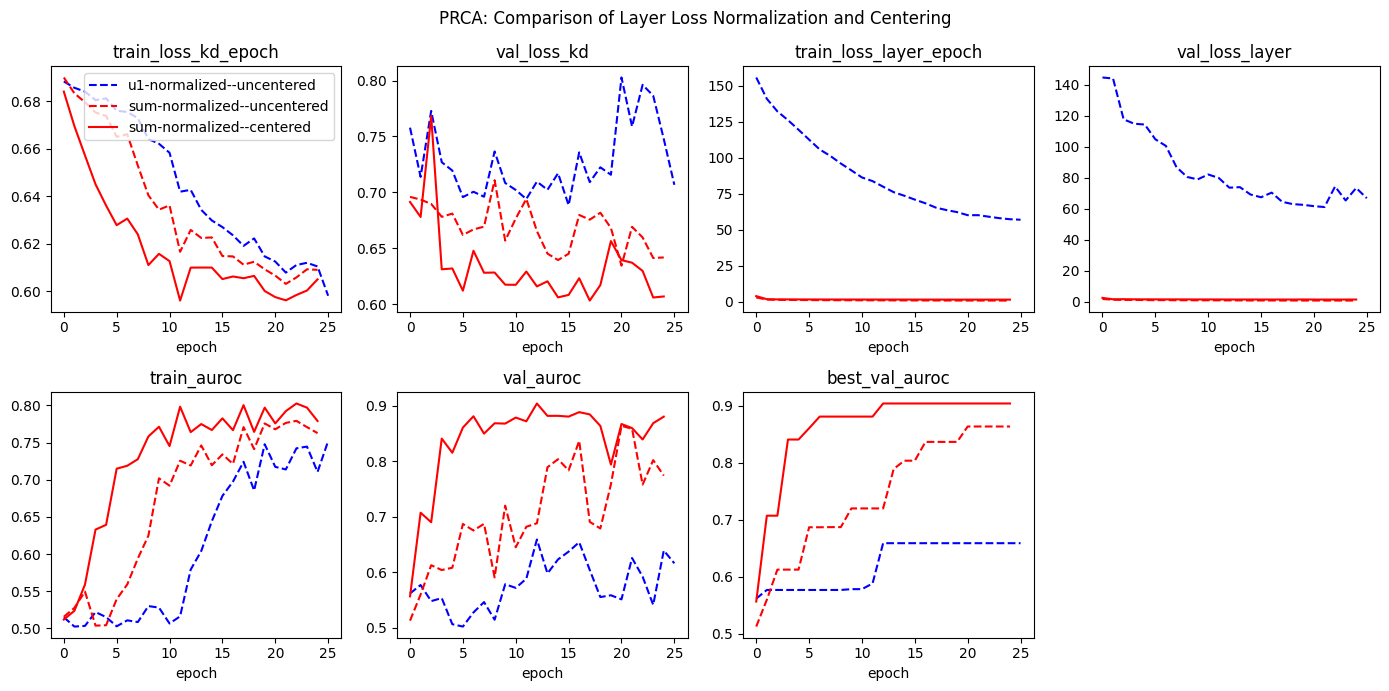

In [44]:
def viz():
    
    arr_cols = [
        "train_loss_kd_epoch",  "val_loss_kd", 
        "train_loss_layer_epoch", "val_loss_layer", 
         "train_auroc", "val_auroc",
        "best_val_auroc",
    ]
    
    ncols = 4
    nrows = 2
    def get_color_ls (name):
        color =  "blue" if "u1-normalized" in name else "red"
        ls = "-" if "--centered" in name else "--"
        
        return color, ls
    
    plt.figure(figsize=(3.5*ncols, 3.5*nrows))
    for cix, col_name in enumerate(arr_cols):
        plt.subplot(nrows, ncols, cix+1)
        
        plt.title(col_name)
        plt.xlabel("epoch")
        
        for run_name in [
            "u1-normalized--uncentered",
            "sum-normalized--uncentered",
            "sum-normalized--centered",
        ]:
            df = read_stats_from_run(MAPPING_RUNID[run_name])
            df = df[df["epoch"] <= 25]
            color, ls = get_color_ls(run_name)
            plt.plot(
                df["epoch"],
                df[col_name],
                label=run_name,
                color=color,
                ls=ls,
            )
        if cix == 0:
            plt.legend()
    plt.suptitle("PRCA: Comparison of Layer Loss Normalization and Centering")
    plt.tight_layout()
viz()